# Step 2: Build and Review QC Inventory


This notebook creates the QC tables used to decide which records can move into metric calculations. Observed and synthetic records are tracked separately, and a comparison is only eligible when both sides pass for the requested metric, component, and period band.

For small tutorial data, the QC inventory can still run locally. For large project data, set `notebook_overrides["submit_qc_to_slurm"] = True` in the configuration cell so the notebook submits the heavy inventory build and the later cells consume the checkpointed output files in chunks.

## Imports

These helpers build QC rows, create comparison-ready records, export a manual-review queue, launch the QC dashboard, and make QC overview figures.


In [1]:
from spatial_vtk.config.notebook import notebook_timer, register_svtk_cell_timer

with notebook_timer():
    from pathlib import Path

    import pandas as pd

    from spatial_vtk.config import SpatialVTKConfig
    from spatial_vtk.config.metrics import metrics_settings_from_config
    from spatial_vtk.config.outputs import resolve_output_path
    from spatial_vtk.io import load_output_table, waveform_preprocessing_label, write_output_table
    from spatial_vtk.qc import (
        build_event_station_pair_retention_table_from_qc_inventory,
        build_metric_pair_retention_table_from_qc_inventory,
        build_metric_qc_summary,
        build_post_qc_record_table_from_qc_inventory,
        build_qc_drop_cause_table_from_qc_inventory,
        build_qc_waveform_comparison_records,
        build_waveform_qc_summary,
        export_manual_review_queue_from_qc_inventory,
        load_comparison_eligible_records,
        write_comparison_eligibility_from_qc_inventory,
    )
    from spatial_vtk.qc.build.slurm import slurm_settings_from_config, submit_qc_slurm_job
    from spatial_vtk.visualize.dashboard import launch_qc_dashboard
    from spatial_vtk.visualize.waveforms import plot_event_trace_comparison
    from spatial_vtk.visualize.qc import (
        plot_event_station_retention_heatmap,
        plot_post_qc_station_event_map,
        plot_qc_drop_cause_diagnostics,
        plot_retention_summary,
    )
    register_svtk_cell_timer()

Run time: 564.8 ms


## Configuration

Load the tutorial config and set the output folder for this QC step.


In [2]:
from pathlib import Path

# Use the repository root so paths match the public source checkout.
repo_root = Path.cwd()
config_path = repo_root / "data/examples/configuration/example_spatial_vtk_config.yaml"

# Load the tutorial run scenario and make it the active config for later package calls.
cfg = SpatialVTKConfig.from_file(config_path, run_scenario="tutorial").activate()

notebook_overrides = {
    "qc_dashboard_port": 8502,
    # Set this to True on CARC or another SLURM cluster for large datasets.
    "submit_qc_to_slurm": False,
    # Keep this True for the small tutorial data. Set it False when submitting to SLURM.
    "run_qc_locally": True,
    "qc_chunksize": 1_000_000,
    "comparison_preview_rows": 5_000,
}

Run time: 21.2 ms


## Load the Step 1 Files

Start from the prepared station, event, and event-station tables written by the first notebook.

In [3]:
# Read the prepared station table written by Step 1.
stations = load_output_table("prepared_stations")

# Read the prepared event table written by Step 1.
events = load_output_table("prepared_events")

# Read the event-station record table written by Step 1.
event_stations = load_output_table("event_station_records")

print(f"Prepared stations: {len(stations)}")
print(f"Prepared events: {len(events)}")
print(f"Event-station records: {len(event_stations)}")

Prepared stations: 30
Prepared events: 5
Event-station records: 150
Run time: 113.0 ms


Use the QC helpers to inspect the observed and synthetic traces, then apply those decisions to the metric-level QC table. Observed and synthetic records are checked separately. A record is available for comparison only when both sides pass.

The heavy QC build writes checkpointed tables. If a SLURM job is submitted, wait for it to finish before running the later cells; those cells read the output files directly and stream large tables in chunks.

In [4]:
# Resolve metrics, components, passbands, and spectral settings from the active config.
metric_settings = metrics_settings_from_config()
trace_qc_path = resolve_output_path("qc_trace_summary", kind="table", create_parent=True)
qc_inventory_path = resolve_output_path("qc_inventory", kind="table", create_parent=True)

submit_qc_to_slurm = bool(notebook_overrides.get("submit_qc_to_slurm", False))
run_qc_locally = bool(notebook_overrides.get("run_qc_locally", not submit_qc_to_slurm))

if submit_qc_to_slurm:
    # SLURM jobs run in a separate process, so first save the in-memory table.
    event_station_path = write_output_table("event_station_records", event_stations)

    slurm_root = Path(cfg.path("outputs.root", create_parent=True) or cfg.root_dir / "outputs")
    slurm_script = slurm_root / "slurm" / "build_qc_inventory.slurm"
    slurm_script.parent.mkdir(parents=True, exist_ok=True)

    settings = slurm_settings_from_config(cfg)
    submission = submit_qc_slurm_job(
        event_station_path,
        slurm_script,
        settings,
        config_path=cfg.config_path,
        trace_qc_output=trace_qc_path,
        qc_inventory_output=qc_inventory_path,
    )
    print(submission.stdout)
    if submission.stderr:
        print(submission.stderr)
    print(f"script: {submission.script_path}")
    print(f"job_id: {submission.job_id}")
    print(f"logs: {settings.log_dir}/svtk-qc_<job_id>.out")
    print(f"trace QC output: {trace_qc_path}")
    print(f"QC inventory output: {qc_inventory_path}")
    if submission.returncode != 0:
        raise RuntimeError(f"SLURM submission failed with return code {submission.returncode}")
    qc_summary_preview = pd.read_csv(qc_inventory_path, nrows=5, low_memory=False) if qc_inventory_path.exists() else pd.DataFrame()
elif run_qc_locally:
    # Local mode is intended for small tutorial/subset data. Large project data should use SLURM.
    trace_qc_summary = build_waveform_qc_summary(
        event_stations,
        components=metric_settings.components,
        passbands=metric_settings.passbands,
        verbose=True,
        checkpoint_path=trace_qc_path,
    )
    write_output_table("qc_trace_summary", trace_qc_summary)

    qc_summary = build_metric_qc_summary(
        event_stations,
        metrics=metric_settings.metrics,
        components=metric_settings.components,
        passbands=metric_settings.passbands,
        spectral_periods_s=metric_settings.spectral.periods_s,
        synthetic_max_frequency_hz=metric_settings.synthetic_max_frequency_hz,
        trace_qc_summary=trace_qc_summary,
        verbose=True,
        checkpoint_path=qc_inventory_path,
    )
    write_output_table("qc_inventory", qc_summary)
    qc_summary_preview = qc_summary.head()
else:
    print("Skipping QC build. Using existing output files:")
    print(f"trace QC output: {trace_qc_path}")
    print(f"QC inventory output: {qc_inventory_path}")
    qc_summary_preview = pd.read_csv(qc_inventory_path, nrows=5, low_memory=False) if qc_inventory_path.exists() else pd.DataFrame()

qc_summary_preview

,source,event_id,station,event_title,event_lat,event_lon,station_lat,station_lon,network,magnitude,distance_km,component,passband,metric_group,metric,period_s,qc_status,qc_reason
0,observed,ci38038071,BFS,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501,Z,1-2 sec,amplitude,PGA,NaN,pass,
1,observed,ci38038071,BFS,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501,Z,2-3 sec,amplitude,PGA,NaN,pass,
2,observed,ci38038071,BFS,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501,Z,1-2 sec,amplitude,PGV,NaN,pass,
3,observed,ci38038071,BFS,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501,Z,2-3 sec,amplitude,PGV,NaN,pass,
4,observed,ci38038071,BFS,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501,Z,1-2 sec,amplitude,PGD,NaN,pass,


Run time: 13.25 s


## Find Comparison-Eligible Records

A row is comparison-ready when the observed side and synthetic side both pass for the same event, station, component, passband, metric, and period.


In [5]:
# Keep only rows where observed and synthetic data both pass QC.
if not qc_inventory_path.exists():
    raise FileNotFoundError(f"QC inventory is not available yet: {qc_inventory_path}")

comparison_eligible_path = resolve_output_path("comparison_eligible_records", kind="table", create_parent=True)
write_comparison_eligibility_from_qc_inventory(
    qc_inventory_path,
    comparison_eligible_path,
    chunksize=notebook_overrides["qc_chunksize"],
    overwrite=False,
    verbose=True,
)

comparison_eligible_preview = load_comparison_eligible_records(
    comparison_eligible_path,
    max_records=5,
    chunksize=notebook_overrides["qc_chunksize"],
)
print(f"comparison-eligible records: {comparison_eligible_path}")
comparison_eligible_preview

,source_observed,event_id,station,component,passband,metric_group,metric,period_s,qc_status_observed,qc_reason_observed,...,qc_status_synthetic,qc_reason_synthetic,event_title,event_lat,event_lon,station_lat,station_lon,network,magnitude,distance_km
0,observed,ci38038071,BFS,Z,1-2 sec,amplitude,PGA,NaN,pass,,...,pass,,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501
1,observed,ci38038071,BFS,Z,2-3 sec,amplitude,PGA,NaN,pass,,...,pass,,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501
2,observed,ci38038071,BFS,Z,1-2 sec,amplitude,PGV,NaN,pass,,...,pass,,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501
3,observed,ci38038071,BFS,Z,2-3 sec,amplitude,PGV,NaN,pass,,...,pass,,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501
4,observed,ci38038071,BFS,Z,1-2 sec,amplitude,PGD,NaN,pass,,...,pass,,ci38038071,34.136333,-117.774667,34.239,-117.659,CI,4.38,15.60501


Run time: 225.8 ms


## Make QC Figures

These figures summarize QC pass/fail counts, retained comparison pairs by event and station, station-event coverage after QC, and reasons records were dropped.

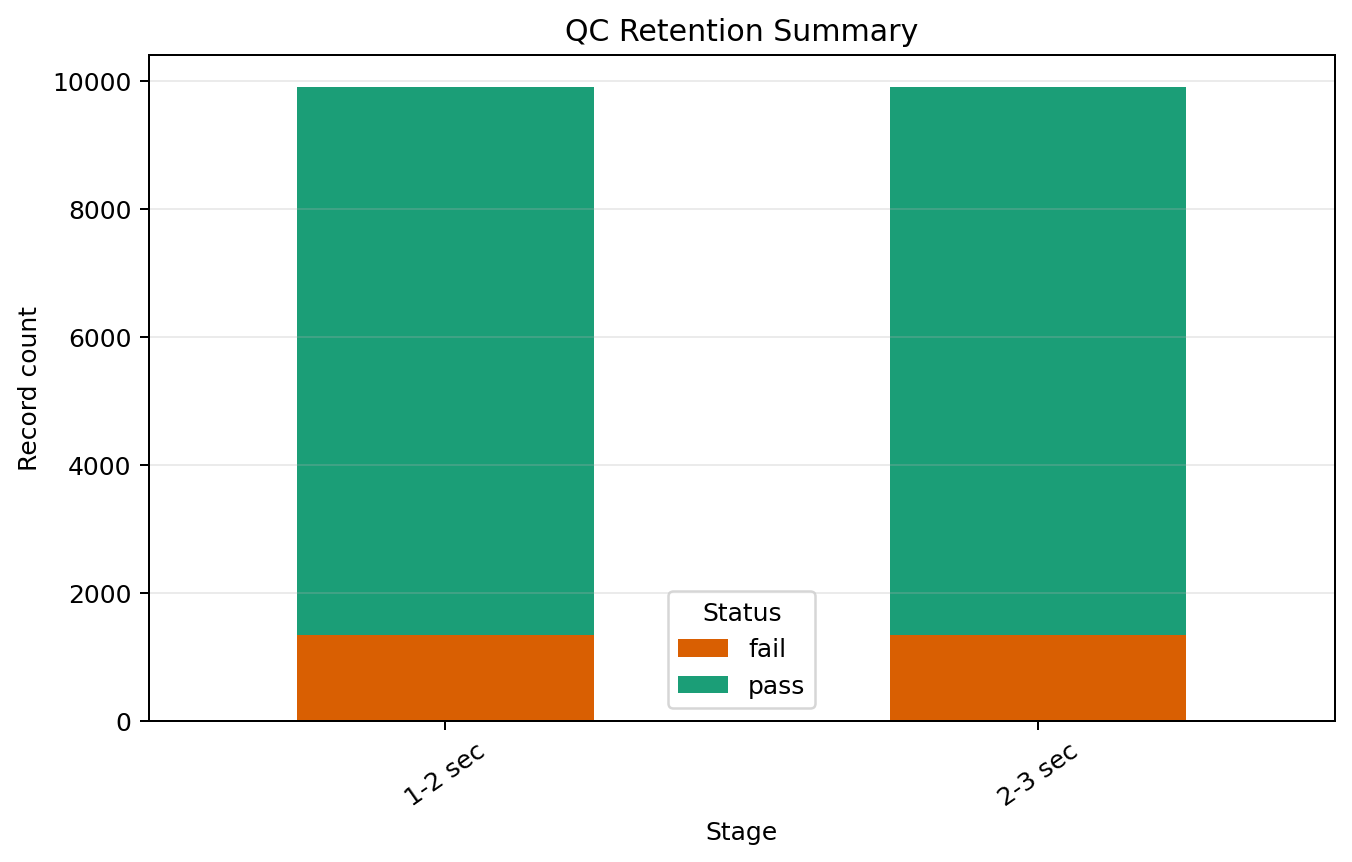

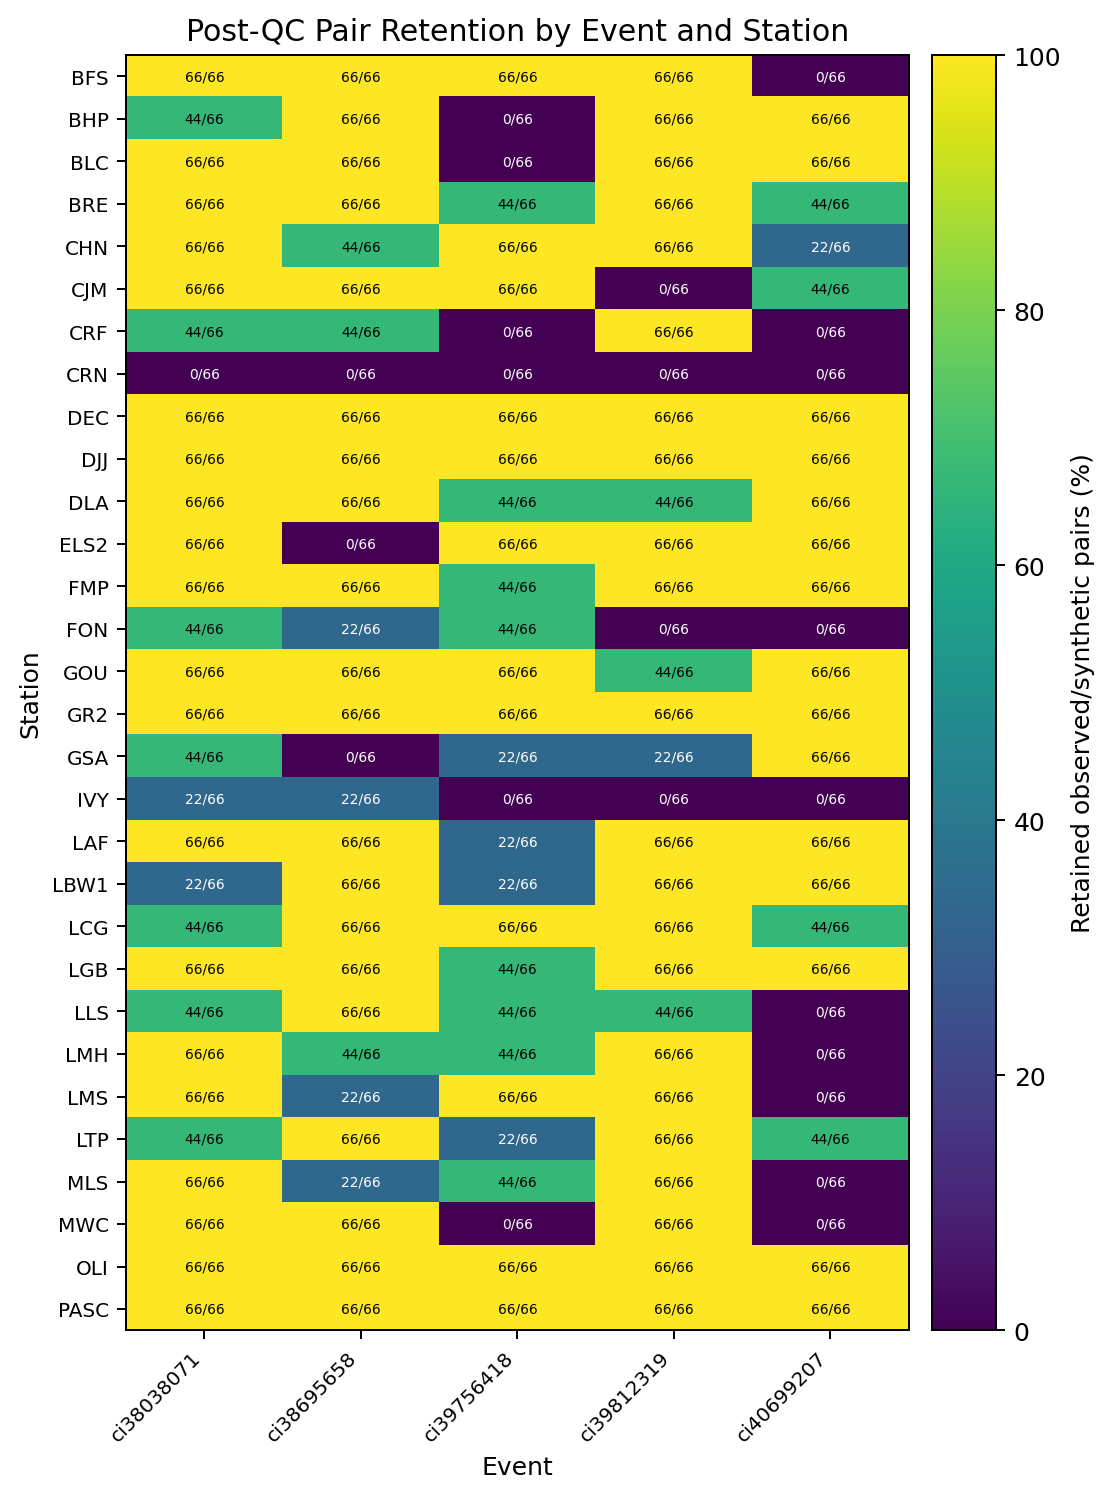

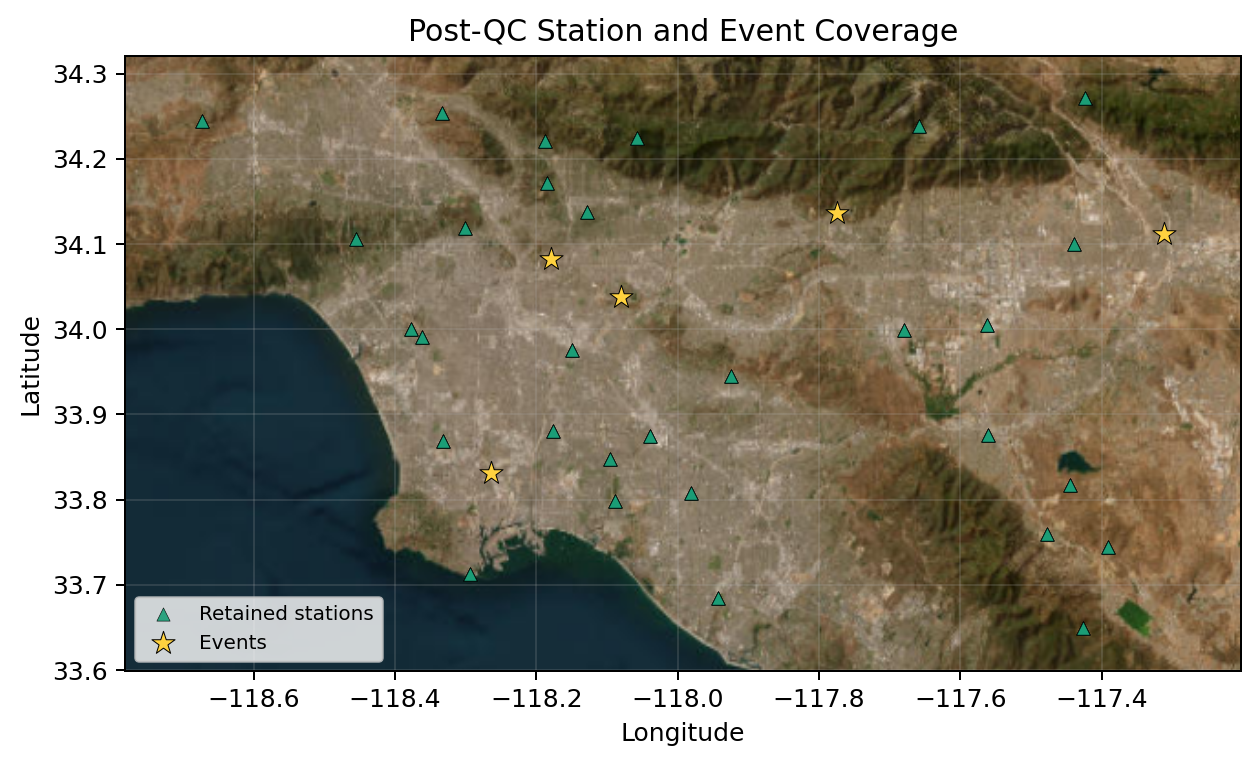

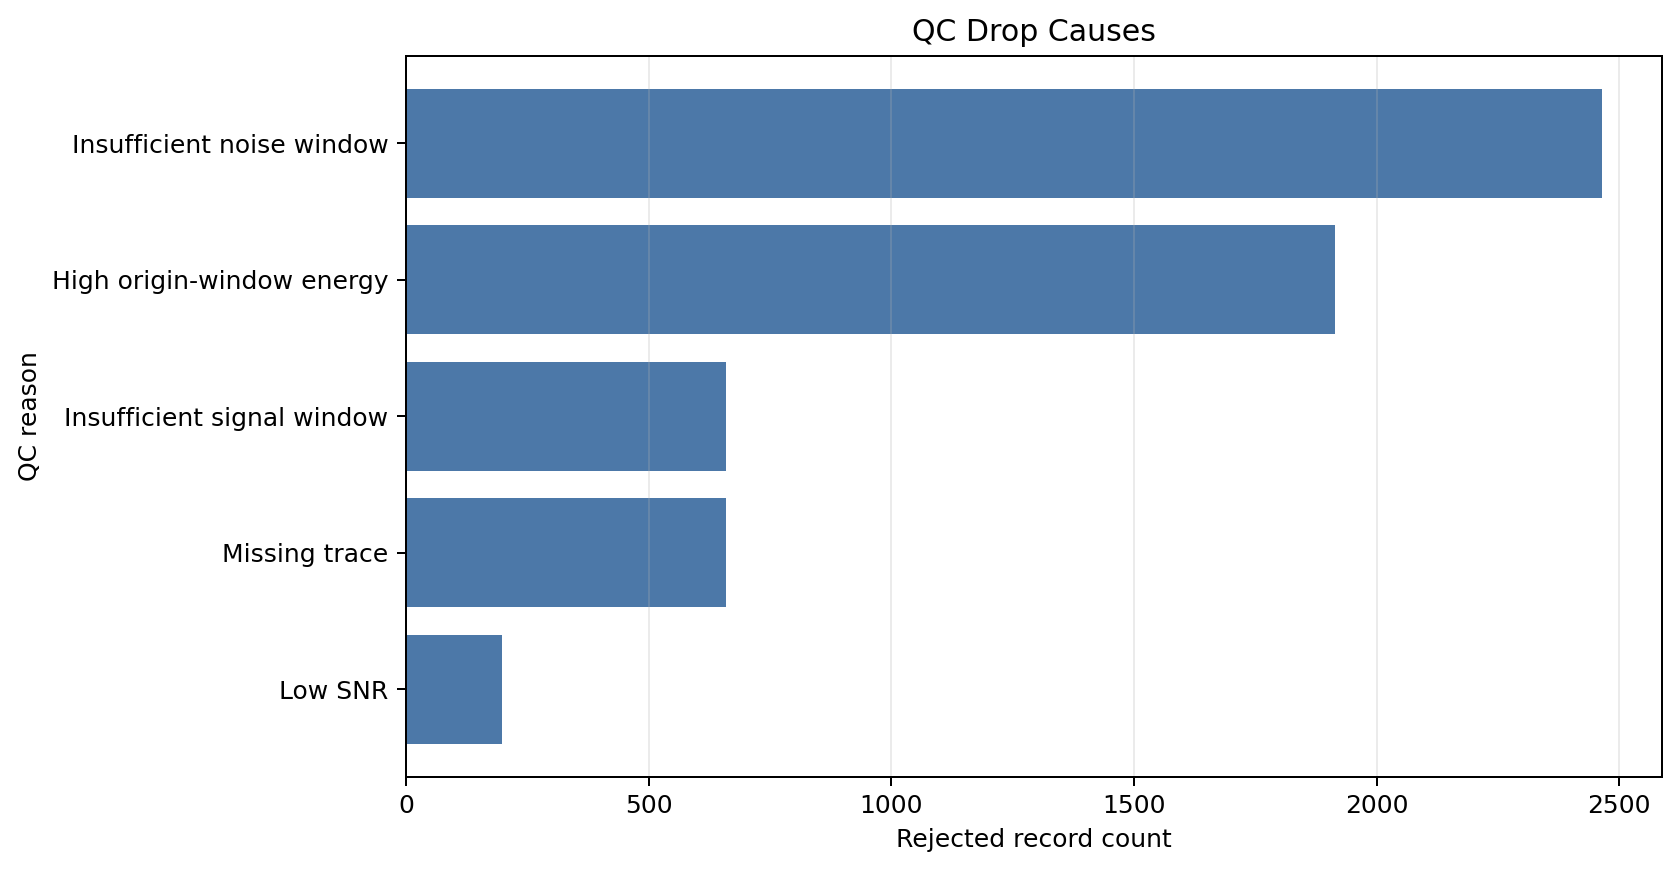

Run time: 4.19 s


In [6]:
# Summarize retained observed/synthetic comparison pairs by metric and passband without loading the full QC inventory.
retention_table = build_metric_pair_retention_table_from_qc_inventory(
    qc_inventory_path,
    chunksize=notebook_overrides["qc_chunksize"],
    verbose=True,
)

# Summarize retained observed/synthetic comparison pairs for each station-event pair.
event_station_retention = build_event_station_pair_retention_table_from_qc_inventory(
    qc_inventory_path,
    chunksize=notebook_overrides["qc_chunksize"],
    verbose=True,
)

# Join post-QC decisions back to event and station coordinates for mapping.
post_qc_records = build_post_qc_record_table_from_qc_inventory(
    event_stations,
    events=events,
    qc_summary=qc_inventory_path,
    chunksize=notebook_overrides["qc_chunksize"],
    pair_retention=event_station_retention,
    verbose=True,
)

# Summarize rejection reasons as compact counts for diagnostics.
drop_cause_table = build_qc_drop_cause_table_from_qc_inventory(
    qc_inventory_path,
    chunksize=notebook_overrides["qc_chunksize"],
    verbose=True,
)

# QC retention summary: retained pair percentages by metric and period band.
retention_fig = plot_retention_summary(
    retention_table,
    title="QC Pair Retention Summary",
    showfig=True,
    savefig=True,
)

# Event-station heatmap: percentage of comparison pairs retained across components, passbands, and metrics.
availability_fig = plot_event_station_retention_heatmap(
    event_station_retention,
    title="Post-QC Pair Retention by Event and Station",
    showfig=True,
    savefig=True,
)

# Post-QC map: where accepted and rejected event-station records are located.
post_qc_fig = plot_post_qc_station_event_map(post_qc_records, add_basemap=True, showfig=True, savefig=True)

# Drop-cause diagnostics: the main reasons records were removed.
drop_cause_fig = plot_qc_drop_cause_diagnostics(
    drop_cause_table,
    reason_col="_reason",
    status_col=None,
    count_col="count",
    showfig=True,
    savefig=True,
)

## Inspect QC-Passed Waveforms

Before opening the dashboard, plot a small set of retained R-component observed/synthetic waveform pairs. These are the processed waveforms that passed QC, limited to nearby stations so you can quickly check whether the traces look comparable.

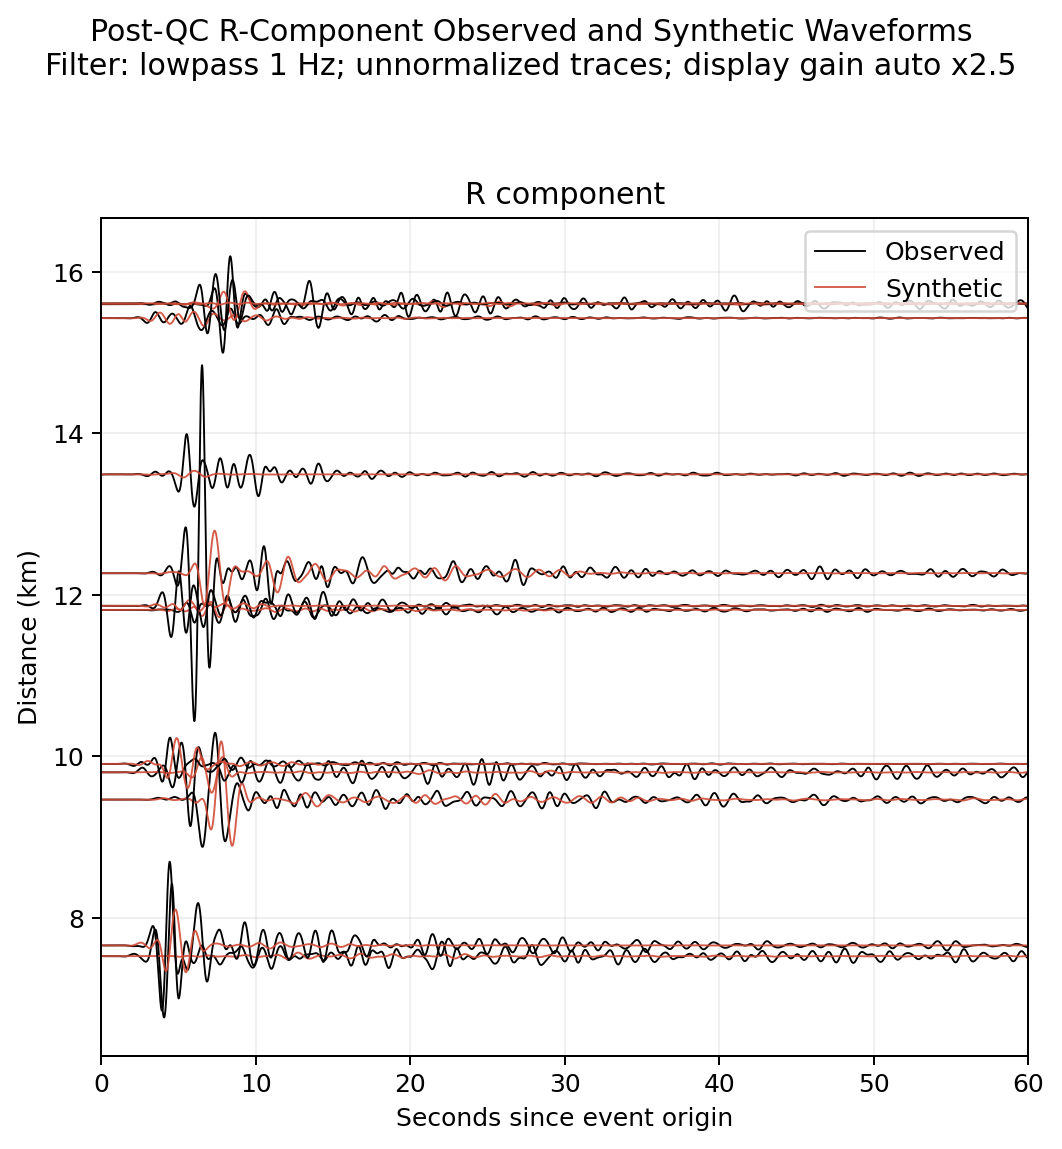

Waveform pairs shown: 12
Run time: 1.19 s


In [7]:
# Load a bounded sample of QC-passed R-component observed/synthetic waveform pairs within 50 km.
comparison_eligible_sample = load_comparison_eligible_records(
    comparison_eligible_path,
    component="R",
    max_records=notebook_overrides["comparison_preview_rows"],
    chunksize=notebook_overrides["qc_chunksize"],
)

waveform_preview = build_qc_waveform_comparison_records(
    event_stations,
    comparison_eligible=comparison_eligible_sample,
    component="R",
    max_distance_km=50,
    max_records=12,
)

# Plot unnormalized waveforms with boosted automatic display gain so relative observed/synthetic amplitudes are preserved.
waveform_comparison_fig = plot_event_trace_comparison(
    waveform_preview,
    normalize=False,
    amplitude_gain="auto",
    amplitude_gain_multiplier=2.5,
    distance_limit_km=None,
    time_limit_s=60,
    title="Post-QC R-Component Observed and Synthetic Waveforms",
    filter_label=f"{waveform_preprocessing_label()}; unnormalized traces; display gain auto x2.5",
    showfig=True,
    savefig=True,
)
print(f"Waveform pairs shown: {len(waveform_preview)}")

## Open the QC Dashboard

The QC dashboard opens with the table you just wrote. The Manual Review Queue tab lets you inspect the queue and download the picker-ready CSV.


In [8]:
# Export a manual-review queue that the manual QC picker can read without loading the full QC inventory.
manual_queue_path = export_manual_review_queue_from_qc_inventory(
    qc_inventory_path,
    chunksize=notebook_overrides["qc_chunksize"],
    overwrite=False,
    verbose=True,
)

# Launch the QC dashboard when you run the notebook interactively.
qc_process = launch_qc_dashboard(
    server_port=notebook_overrides["qc_dashboard_port"],
    show=True,
)
print(f"QC dashboard: http://127.0.0.1:{notebook_overrides['qc_dashboard_port']}")
print(f"Manual-review queue: {manual_queue_path.relative_to(repo_root)}")

QC dashboard: http://127.0.0.1:8502
Manual-review queue: outputs/tutorials/tables/manual_review_queue.csv
Run time: 151.4 ms
